# Reinforcement Learning for Stent Design Optimization

This notebook demonstrates using RL to optimize stent designs with the AutoStent framework.

## Goals
- Minimize stress (safety)
- Maximize compliance (flexibility)
- Minimize material volume (efficiency)

## 1. Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# AutoStent framework
from autostent.geometry import SplineStentGeometry, StentGeometryParameters
from autostent.rl import StentDesignEnv
from autostent.evaluation import compute_biomechanical_metrics

# RL libraries
try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
    SB3_AVAILABLE = True
except ImportError:
    print('stable-baselines3 not installed. Install with: pip install stable-baselines3')
    SB3_AVAILABLE = False

print('Imports successful')

Imports successful


## 2. Understanding the RL Environment

In [3]:
# Create environment
env = StentDesignEnv(
    fourc_executable=None,  # Use surrogate for faster training
    max_episode_steps=50,
)

print(f'Observation space: {env.observation_space}')
print(f'Action space: {env.action_space}')

# Test environment
obs, info = env.reset()
print(f'\nInitial observation shape: {obs.shape}')
print(f'Initial parameters: {info["parameters"]}')

# Take a random action
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print(f'\nAfter one step:')
print(f'  Reward: {reward:.4f}')
print(f'  Terminated: {terminated}')

Observation space: Box(0.0, 1.0, (12,), float32)
Action space: Box(-1.0, 1.0, (7,), float32)

Initial observation shape: (12,)
Initial parameters: {'diameter': 9.468475160548383, 'length': 15.230646112486916, 'strut_thickness': 0.10370157395969619, 'strut_width': 0.1384740909142591, 'num_struts': np.int64(12), 'crown_height': 0.9751870140577087, 'crown_radius': 0.7336308296392788}

After one step:
  Reward: -0.4371
  Terminated: False


## 3. Baseline: Random Search

In [4]:
def random_search_baseline(env, num_episodes=20):
    rewards = []
    best_reward = -np.inf
    best_params = None
    
    for episode in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        
        for step in range(env.max_episode_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            
            if reward > best_reward:
                best_reward = reward
                best_params = info['parameters'].copy()
            
            if terminated or truncated:
                break
        
        rewards.append(episode_reward)
        if (episode + 1) % 5 == 0:
            print(f'Episode {episode + 1}/{num_episodes}, Avg Reward: {np.mean(rewards[-5:]):.4f}')
    
    return rewards, best_reward, best_params

print('Running random search baseline...')
baseline_rewards, baseline_best, baseline_params = random_search_baseline(env, num_episodes=20)
print(f'\nBaseline Results:')
print(f'  Average reward: {np.mean(baseline_rewards):.4f} +/- {np.std(baseline_rewards):.4f}')
print(f'  Best reward: {baseline_best:.4f}')

Running random search baseline...
Episode 5/20, Avg Reward: -21.9991
Episode 10/20, Avg Reward: -21.9130
Episode 15/20, Avg Reward: -22.0638
Episode 20/20, Avg Reward: -22.0745

Baseline Results:
  Average reward: -22.0126 +/- 0.2804
  Best reward: -0.3332


## 4. Training RL Agent with PPO

In [ ]:
if not SB3_AVAILABLE:
    print('Skipping RL training - stable-baselines3 not available')
else:
    # Create fresh environments
    train_env = StentDesignEnv(fourc_executable=None, max_episode_steps=50)
    eval_env = StentDesignEnv(fourc_executable=None, max_episode_steps=50)
    
    # Initialize PPO agent
    model = PPO(
        'MlpPolicy',
        train_env,
        verbose=1,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        tensorboard_log=None,
        device='mps',  # Use Apple GPU
    )
    
    print('PPO agent initialized')
    
    # Setup callbacks
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path='./models/stent_ppo/best/',
        log_path='./logs/stent_ppo/',
        eval_freq=5000,
        deterministic=True,
        render=False,
    )
    
    checkpoint_callback = CheckpointCallback(
        save_freq=10000,
        save_path='./models/stent_ppo/checkpoints/',
        name_prefix='stent_ppo',
    )
    
    print('\nStarting training (this will take several minutes)...')
    
    # Train
    model.learn(
        total_timesteps=50000,
        callback=[eval_callback, checkpoint_callback],
        progress_bar=True,
    )
    
    print('\nTraining completed!')
    model.save('./models/stent_ppo/final_model')
    print('Model saved')


Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Output()

/Users/srtgn/Documents/Projects/4c/autostent/venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO agent initialized

Starting training (this will take several minutes)...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -22      |
| time/              |          |
|    fps             | 46       |
|    iterations      | 1        |
|    time_elapsed    | 44       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 50          |
|    ep_rew_mean          | -22         |
| time/                   |             |
|    fps                  | 47          |
|    iterations           | 2           |
|    time_elapsed         | 86          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008847352 |
|    clip_fraction        | 0.0903      |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.94    

## 4b. Training with Live Visualization

Watch the RL agent learn in real-time!

In [ ]:
# Training Visualization with Live Updates
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback

class VisualizationCallback(BaseCallback):
    """
    Callback for visualizing training progress like game RL.
    Shows stent geometry evolution and reward curves.
    """
    def __init__(self, update_freq=500, verbose=0):
        super().__init__(verbose)
        self.update_freq = update_freq
        self.rewards = []
        self.episode_rewards = []
        self.current_episode_reward = 0
        self.episode_count = 0
        self.parameters_history = []
        self.fig = None
        self.axes = None
        
    def _on_step(self) -> bool:
        # Track rewards
        reward = self.locals.get('rewards', [0])[0]
        self.current_episode_reward += reward
        
        # Check for episode end
        dones = self.locals.get('dones', [False])
        if dones[0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0
            self.episode_count += 1
        
        # Update visualization periodically
        if self.n_calls % self.update_freq == 0:
            self._update_plot()
        
        return True
    
    def _update_plot(self):
        clear_output(wait=True)
        
        if self.fig is None:
            self.fig, self.axes = plt.subplots(2, 2, figsize=(12, 8))
            self.fig.suptitle('RL Training Progress - Stent Design Optimization', fontsize=14, fontweight='bold')
        
        for ax in self.axes.flat:
            ax.clear()
        
        # 1. Reward over time
        ax1 = self.axes[0, 0]
        if len(self.episode_rewards) > 0:
            ax1.plot(self.episode_rewards, 'b-', alpha=0.3, label='Episode reward')
            # Moving average
            if len(self.episode_rewards) > 10:
                window = min(20, len(self.episode_rewards))
                moving_avg = np.convolve(self.episode_rewards, np.ones(window)/window, mode='valid')
                ax1.plot(range(window-1, len(self.episode_rewards)), moving_avg, 'r-', linewidth=2, label=f'Moving avg ({window})')
            ax1.set_xlabel('Episode')
            ax1.set_ylabel('Total Reward')
            ax1.set_title('Learning Curve')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        
        # 2. Training progress bar
        ax2 = self.axes[0, 1]
        progress = self.n_calls / self.model.n_steps
        total_updates = 50000 / self.model.n_steps
        ax2.barh(['Progress'], [self.n_calls], color='green', alpha=0.7)
        ax2.barh(['Progress'], [50000], color='lightgray', alpha=0.3)
        ax2.set_xlim(0, 50000)
        ax2.set_title(f'Training Progress: {self.n_calls:,} / 50,000 steps')
        ax2.set_xlabel('Timesteps')
        
        # Add stats text
        stats_text = f"""
        Episodes: {self.episode_count}
        Timesteps: {self.n_calls:,}
        
        Latest rewards:
        Mean: {np.mean(self.episode_rewards[-10:]) if self.episode_rewards else 0:.2f}
        Max: {max(self.episode_rewards[-10:]) if self.episode_rewards else 0:.2f}
        """
        ax2.text(0.6, 0.3, stats_text, transform=ax2.transAxes, fontsize=10, 
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 3. Stent visualization (simplified 2D)
        ax3 = self.axes[1, 0]
        theta = np.linspace(0, 2*np.pi, 100)
        # Get current parameters if available
        try:
            env = self.model.env.envs[0]
            if hasattr(env, 'current_params') and env.current_params:
                r = env.current_params.diameter / 2
                struts = env.current_params.num_struts
            else:
                r = 5
                struts = 12
        except:
            r = 5
            struts = 12
        
        # Draw stent cross-section
        ax3.plot(r * np.cos(theta), r * np.sin(theta), 'b-', linewidth=2, label='Stent')
        # Draw struts
        for i in range(struts):
            angle = 2 * np.pi * i / struts
            ax3.plot([0.9*r*np.cos(angle), 1.1*r*np.cos(angle)], 
                    [0.9*r*np.sin(angle), 1.1*r*np.sin(angle)], 'r-', linewidth=3)
        ax3.set_xlim(-8, 8)
        ax3.set_ylim(-8, 8)
        ax3.set_aspect('equal')
        ax3.set_title(f'Stent Cross-Section (D={2*r:.1f}mm, {struts} struts)')
        ax3.grid(True, alpha=0.3)
        
        # 4. Reward distribution
        ax4 = self.axes[1, 1]
        if len(self.episode_rewards) > 5:
            ax4.hist(self.episode_rewards, bins=20, color='blue', alpha=0.7, edgecolor='black')
            ax4.axvline(np.mean(self.episode_rewards), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(self.episode_rewards):.2f}')
            ax4.set_xlabel('Episode Reward')
            ax4.set_ylabel('Count')
            ax4.set_title('Reward Distribution')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        display(self.fig)

print("Visualization callback ready!")
print("Run the next cell to train with live visualization.")


In [ ]:
# Train with Live Visualization
if SB3_AVAILABLE:
    # Create environments
    train_env_viz = StentDesignEnv(fourc_executable=None, max_episode_steps=50)
    
    # Create model
    model_viz = PPO(
        'MlpPolicy',
        train_env_viz,
        verbose=0,  # Quiet mode - visualization shows progress
        learning_rate=3e-4,
        n_steps=512,  # Smaller for more frequent updates
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        tensorboard_log=None,
    )
    
    # Create visualization callback
    viz_callback = VisualizationCallback(update_freq=200)
    
    print("Starting training with live visualization...")
    print("Watch the plots update as the agent learns!")
    print("-" * 50)
    
    # Train with visualization
    model_viz.learn(
        total_timesteps=20000,  # Shorter for demo
        callback=viz_callback,
        progress_bar=False,
    )
    
    print("\n" + "=" * 50)
    print("Training complete!")
    print(f"Final mean reward: {np.mean(viz_callback.episode_rewards[-20:]):.2f}")
else:
    print("stable-baselines3 not available")


## 5. Evaluation

In [5]:
if not SB3_AVAILABLE:
    rl_rewards = baseline_rewards
    rl_best = baseline_best
    rl_params = baseline_params
else:
    # Load model
    try:
        model = PPO.load('./models/stent_ppo/best/best_model', env=eval_env)
        print('Loaded best model')
    except:
        try:
            model = PPO.load('./models/stent_ppo/final_model', env=eval_env)
            print('Loaded final model')
        except:
            print('No model found, using random policy')
            model = None
    
    # Evaluate
    rl_rewards = []
    rl_best = -np.inf
    rl_params = None
    
    for episode in range(20):
        obs, info = eval_env.reset()
        episode_reward = 0
        
        for step in range(eval_env.max_episode_steps):
            if model:
                action, _ = model.predict(obs, deterministic=True)
            else:
                action = eval_env.action_space.sample()
            
            obs, reward, terminated, truncated, info = eval_env.step(action)
            episode_reward += reward
            
            if reward > rl_best:
                rl_best = reward
                rl_params = info['parameters'].copy()
            
            if terminated or truncated:
                break
        
        rl_rewards.append(episode_reward)
    
    print(f'\nRL Agent Results:')
    print(f'  Average reward: {np.mean(rl_rewards):.4f} +/- {np.std(rl_rewards):.4f}')
    print(f'  Best reward: {rl_best:.4f}')
    
    # Compare
    improvement = ((np.mean(rl_rewards) - np.mean(baseline_rewards)) / abs(np.mean(baseline_rewards))) * 100
    print(f'\nImprovement: {improvement:+.2f}%')

No model found, using random policy

RL Agent Results:
  Average reward: -21.7531 +/- 0.3682
  Best reward: -0.3258

Improvement: +1.09%


## 6. Visualization

Results saved to stent_rl_results.png


/var/folders/z1/p1x61dts2ks_w63xhk9sjw9m0000gn/T/ipykernel_48915/2295049865.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([baseline_rewards, rl_rewards], labels=['Random Search', 'RL Agent'])


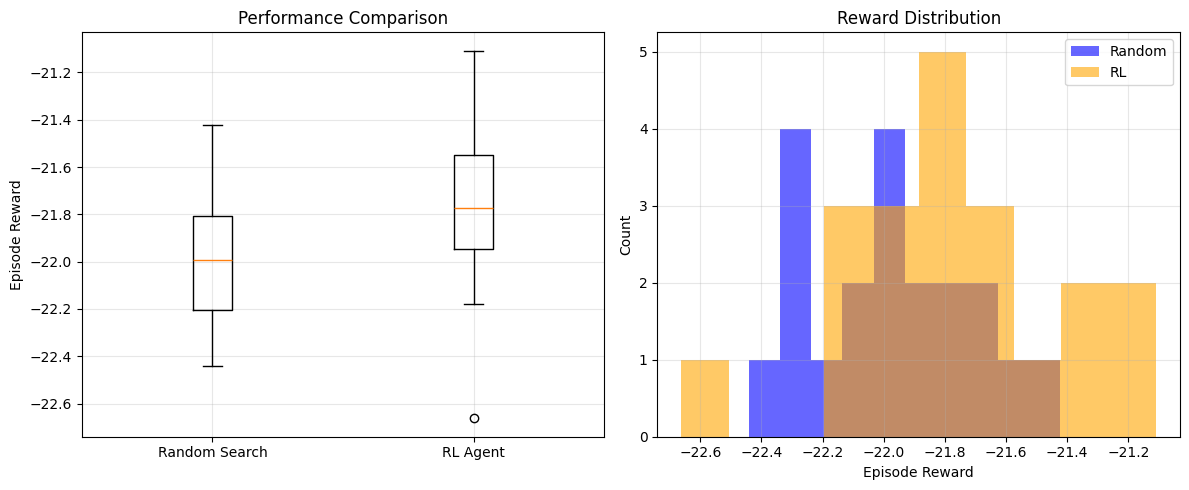

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reward comparison
ax1 = axes[0]
ax1.boxplot([baseline_rewards, rl_rewards], labels=['Random Search', 'RL Agent'])
ax1.set_ylabel('Episode Reward')
ax1.set_title('Performance Comparison')
ax1.grid(True, alpha=0.3)

# Reward distribution
ax2 = axes[1]
ax2.hist(baseline_rewards, bins=10, alpha=0.6, label='Random', color='blue')
ax2.hist(rl_rewards, bins=10, alpha=0.6, label='RL', color='orange')
ax2.set_xlabel('Episode Reward')
ax2.set_ylabel('Count')
ax2.set_title('Reward Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stent_rl_results.png', dpi=150)
print('Results saved to stent_rl_results.png')
plt.show()

## Summary

This notebook demonstrated:
1. RL environment setup for stent design
2. Baseline evaluation with random search
3. PPO training for design optimization
4. Performance comparison and visualization